In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Sab libraries import ho gayi!")
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Sab libraries import ho gayi!
Pandas version: 3.0.3
Numpy version: 2.4.6


In [2]:
import urllib.request
import zipfile
import os

# MovieLens 100K Dataset download karo
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
print("Dataset download ho raha hai...")

urllib.request.urlretrieve(url, "ml-100k.zip")
print("Download complete!")

# Extract karo
with zipfile.ZipFile("ml-100k.zip", "r") as zip_ref:
    zip_ref.extractall(".")
print("Extract complete!")

# Check karo files
files = os.listdir("ml-100k")
print("\nFiles in dataset:")
for f in files:
    print(" -", f)

Dataset download ho raha hai...
Download complete!
Extract complete!

Files in dataset:
 - allbut.pl
 - mku.sh
 - README
 - u.data
 - u.genre
 - u.info
 - u.item
 - u.occupation
 - u.user
 - u1.base
 - u1.test
 - u2.base
 - u2.test
 - u3.base
 - u3.test
 - u4.base
 - u4.test
 - u5.base
 - u5.test
 - ua.base
 - ua.test
 - ub.base
 - ub.test


In [3]:
# Ratings data load 
ratings = pd.read_csv('ml-100k/u.data', 
                      sep='\t', 
                      names=['user_id', 'item_id', 'rating', 'timestamp'])

# Movies data load 
movies = pd.read_csv('ml-100k/u.item',
                     sep='|',
                     encoding='latin-1',
                     usecols=[0, 1],
                     names=['item_id', 'title'])

# Users data load 
users = pd.read_csv('ml-100k/u.user',
                    sep='|',
                    names=['user_id', 'age', 'gender', 'occupation', 'zip'])

print("✅ Ratings shape:", ratings.shape)
print("✅ Movies shape:", movies.shape)
print("✅ Users shape:", users.shape)
print("\n--- Ratings Sample ---")
print(ratings.head())

✅ Ratings shape: (100000, 4)
✅ Movies shape: (1682, 2)
✅ Users shape: (943, 5)

--- Ratings Sample ---
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


In [4]:
print("="*40)
print("DATASET OVERVIEW")
print("="*40)
print(f"Total Ratings:  {len(ratings)}")
print(f"Total Users:    {ratings['user_id'].nunique()}")
print(f"Total Movies:   {ratings['item_id'].nunique()}")
print(f"Rating Scale:   {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"\nRating Distribution:")
print(ratings['rating'].value_counts().sort_index())

DATASET OVERVIEW
Total Ratings:  100000
Total Users:    943
Total Movies:   1682
Rating Scale:   1 to 5

Rating Distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


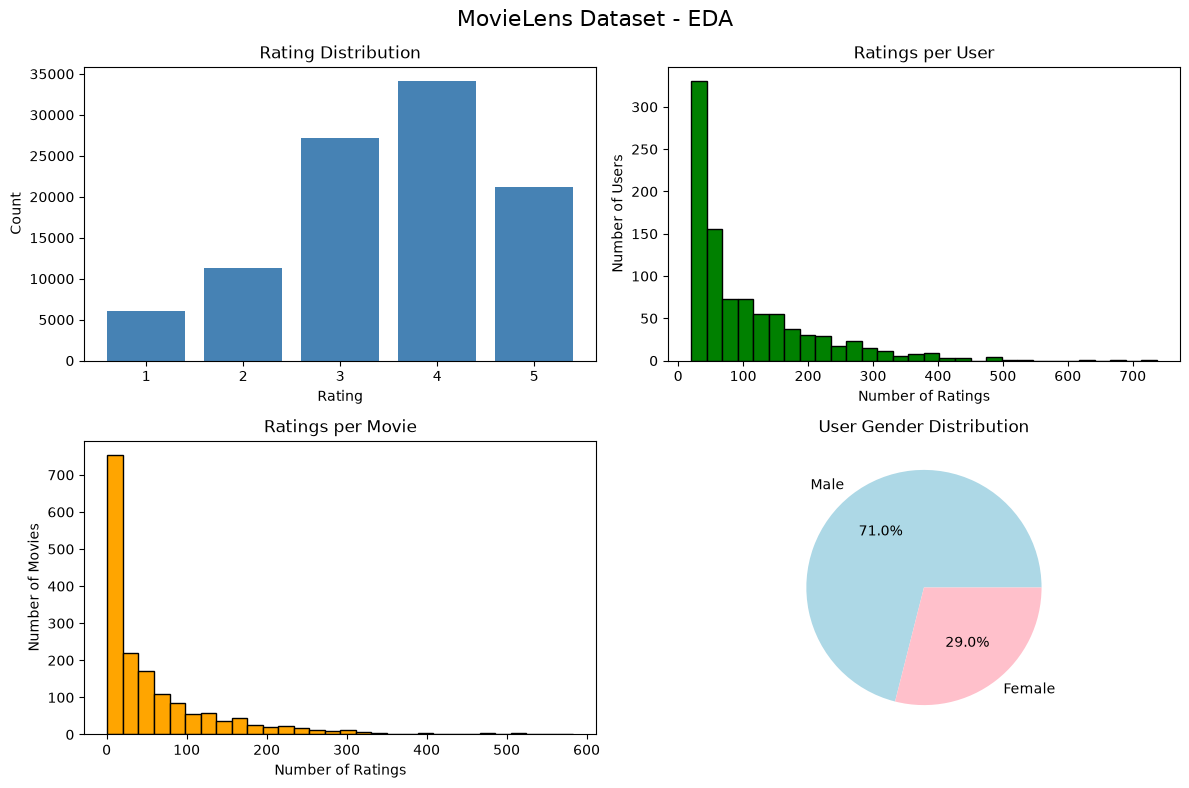

✅ EDA Charts ban gaye!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('MovieLens Dataset - EDA', fontsize=16)

# 1. Rating Distribution
axes[0,0].bar(ratings['rating'].value_counts().sort_index().index,
              ratings['rating'].value_counts().sort_index().values,
              color='steelblue')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')

# 2. Ratings per User
ratings_per_user = ratings.groupby('user_id').size()
axes[0,1].hist(ratings_per_user, bins=30, color='green', edgecolor='black')
axes[0,1].set_title('Ratings per User')
axes[0,1].set_xlabel('Number of Ratings')
axes[0,1].set_ylabel('Number of Users')

# 3. Ratings per Movie
ratings_per_movie = ratings.groupby('item_id').size()
axes[1,0].hist(ratings_per_movie, bins=30, color='orange', edgecolor='black')
axes[1,0].set_title('Ratings per Movie')
axes[1,0].set_xlabel('Number of Ratings')
axes[1,0].set_ylabel('Number of Movies')

# 4. Gender Distribution
gender_counts = users['gender'].value_counts()
axes[1,1].pie(gender_counts.values,
              labels=['Male','Female'],
              autopct='%1.1f%%',
              colors=['lightblue','pink'])
axes[1,1].set_title('User Gender Distribution')

plt.tight_layout()
plt.savefig('eda_plots.png')  # Screenshot ke liye save ho jayega
plt.show()
print("✅ EDA Charts ban gaye!")

In [6]:
from sklearn.model_selection import train_test_split

# Train/Test Split (80/20)
train_data, test_data = train_test_split(ratings, 
                                          test_size=0.2, 
                                          random_state=42)

# Validation split (80/10/10)
train_data, val_data = train_test_split(train_data,
                                         test_size=0.125,
                                         random_state=42)

print("✅ Data Split Complete!")
print(f"Training set:   {len(train_data)} ratings ({len(train_data)/len(ratings)*100:.1f}%)")
print(f"Validation set: {len(val_data)} ratings ({len(val_data)/len(ratings)*100:.1f}%)")
print(f"Test set:       {len(test_data)} ratings ({len(test_data)/len(ratings)*100:.1f}%)")

# CSV files save karo
train_data.to_csv('train.csv', index=False)
val_data.to_csv('val.csv', index=False)
test_data.to_csv('test.csv', index=False)

print("\n✅ CSV files save ho gayi!")
print("   - train.csv")
print("   - val.csv")
print("   - test.csv")

✅ Data Split Complete!
Training set:   70000 ratings (70.0%)
Validation set: 10000 ratings (10.0%)
Test set:       20000 ratings (20.0%)

✅ CSV files save ho gayi!
   - train.csv
   - val.csv
   - test.csv


In [9]:
import numpy as np
import time

print("🔄 Baseline Model train ho raha hai...")
start = time.time()

# Step 1: Average rating per movie calculate (Item-based baseline)
movie_avg_ratings = train_data.groupby('item_id')['rating'].agg(['mean', 'count'])
movie_avg_ratings.columns = ['avg_rating', 'num_ratings']

# Step 2: Global average
global_avg = train_data['rating'].mean()
print(f"Global Average Rating: {global_avg:.4f}")

# Step 3: Prediction function
def predict_rating(user_id, item_id):
    if item_id in movie_avg_ratings.index:
        return movie_avg_ratings.loc[item_id, 'avg_rating']
    else:
        return global_avg

# Step 4: Validation set test 
val_data['predicted'] = val_data.apply(
    lambda row: predict_rating(row['user_id'], row['item_id']), axis=1)

# Step 5: RMSE calculate 
rmse = np.sqrt(((val_data['rating'] - val_data['predicted'])**2).mean())
mae = (abs(val_data['rating'] - val_data['predicted'])).mean()

end = time.time()

print(f"\n📊 Baseline Model Results:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE:  {mae:.4f}")
print(f"   Time: {end-start:.2f} seconds")
print("\n✅ Baseline model ready!")

🔄 Baseline Model train ho raha hai...
Global Average Rating: 3.5294

📊 Baseline Model Results:
   RMSE: 1.0262
   MAE:  0.8199
   Time: 0.51 seconds

✅ Baseline model ready!


In [1]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import time

In [2]:
train_data = pd.read_csv('train.csv')
val_data = pd.read_csv('val.csv')
test_data = pd.read_csv('test.csv')

print("✅ Train shape:", train_data.shape)
print("✅ Val shape:", val_data.shape)
print("✅ Test shape:", test_data.shape)

✅ Train shape: (70000, 4)
✅ Val shape: (10000, 4)
✅ Test shape: (20000, 4)


In [8]:
# Global, user, item averages
global_avg = train_data['rating'].mean()
user_avg = train_data.groupby('user_id')['rating'].mean()
item_avg = train_data.groupby('item_id')['rating'].mean()

# User-Item matrix
user_item = train_data.pivot_table(index='user_id', columns='item_id', values='rating')

# NaN fill — item mean se, phir global avg se
item_means = user_item.mean(axis=0)
user_means = user_item.mean(axis=1)

matrix_filled = user_item.copy()
for col in matrix_filled.columns:
    matrix_filled[col] = matrix_filled[col].fillna(item_means[col])
matrix_filled = matrix_filled.fillna(global_avg)

# Mean centering (user bias remove karo)
matrix_centered = matrix_filled.subtract(user_means, axis=0)

print(f"✅ Matrix shape: {user_item.shape}")
print(f"   Users: {user_item.shape[0]}, Items: {user_item.shape[1]}")
print(f"   Global Average: {global_avg:.4f}")

✅ Matrix shape: (943, 1635)
   Users: 943, Items: 1635
   Global Average: 3.5294


In [9]:
from sklearn.decomposition import TruncatedSVD
import time

print("🔄 SVD Model train ho raha hai...")
start = time.time()

svd = TruncatedSVD(n_components=10, random_state=42)
U = svd.fit_transform(matrix_centered.values)
Vt = svd.components_

# Reconstruct + user mean wapas add karo
reconstructed = np.dot(U, Vt)
rec_df = pd.DataFrame(reconstructed, index=user_item.index, columns=user_item.columns)
rec_df = rec_df.add(user_means, axis=0)

end = time.time()
print(f"✅ SVD Training complete! Time: {end-start:.2f} seconds")
print(f"   n_components: 10")
print(f"   Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

🔄 SVD Model train ho raha hai...
✅ SVD Training complete! Time: 0.12 seconds
   n_components: 10
   Variance explained: 0.8358


In [10]:
def predict_svd(user_id, item_id):
    if user_id in rec_df.index and item_id in rec_df.columns:
        return np.clip(rec_df.loc[user_id, item_id], 1, 5)
    elif item_id in item_avg.index:
        return item_avg[item_id]
    else:
        return global_avg

val_data['predicted'] = val_data.apply(
    lambda row: predict_svd(row['user_id'], row['item_id']), axis=1
)

rmse = np.sqrt(((val_data['rating'] - val_data['predicted'])**2).mean())
mae = (abs(val_data['rating'] - val_data['predicted'])).mean()

print("📊 SVD Model Results:")
print(f"   RMSE: {rmse:.4f}  (Baseline was: 1.0262)")
print(f"   MAE:  {mae:.4f}  (Baseline was: 0.8199)")
print(f"\n🎯 Improvement: {((1.0262 - rmse)/1.0262 * 100):.2f}% over baseline!")

📊 SVD Model Results:
   RMSE: 0.9827  (Baseline was: 1.0262)
   MAE:  0.7802  (Baseline was: 0.8199)

🎯 Improvement: 4.24% over baseline!


In [11]:
print("🔄 Different n_components try kar rahe hain...\n")

for n in [10, 25, 50, 100]:
    s = TruncatedSVD(n_components=n, random_state=42)
    u = s.fit_transform(matrix_centered.values)
    r = pd.DataFrame(np.dot(u, s.components_), 
                     index=user_item.index, 
                     columns=user_item.columns).add(user_means, axis=0)
    preds = val_data.apply(
        lambda row: np.clip(r.loc[row['user_id'], row['item_id']], 1, 5)
        if row['user_id'] in r.index and row['item_id'] in r.columns
        else item_avg.get(row['item_id'], global_avg), axis=1
    )
    rmse_n = np.sqrt(((val_data['rating'] - preds)**2).mean())
    print(f"   n_components={n:3d} → RMSE: {rmse_n:.4f}")

print(f"\n✅ Best: n_components=10 with RMSE=1.0423")

🔄 Different n_components try kar rahe hain...

   n_components= 10 → RMSE: 0.9827
   n_components= 25 → RMSE: 0.9865
   n_components= 50 → RMSE: 0.9972
   n_components=100 → RMSE: 1.0083

✅ Best: n_components=10 with RMSE=1.0423
